### Python 회귀 모델 학습

### Zomato Delivery Dataset

##### Libraries

In [102]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels as stats
from statsmodels.stats.stattools import durbin_watson
import numpy as np

##### Dataset
- Delivery data of specific conditions:
    - Weather: Sunny
    - Traffic: Low
    - Ratings:
        - less than or equal to 3
        - equal to 5 

In [7]:
sunny_3_5 = pd.read_csv("C:/Users/minjk/Downloads/sunny_3_5.csv")
sunny_3_5

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
0,0x8b39,VADRES01DEL01,24.0,2.6,22.307898,73.167788,22.417898,73.277788,2022-04-06,1900-01-01 22:35:00,...,Drinks,motorcycle,1.0,Yes,Metropolitian,42,15,4,22.0,0
1,0x5fd4,SURRES04DEL01,23.0,2.5,21.173493,72.801953,21.283493,72.911953,2022-03-20,1900-01-01 23:50:00,...,Buffet,motorcycle,1.0,No,Metropolitian,34,-153722867280912928,3,23.0,0
2,0xc714,BHPRES14DEL03,29.0,2.5,0.000000,0.000000,0.090000,0.090000,2022-02-18,1900-01-01 22:55:00,...,Drinks,scooter,1.0,Yes,Metropolitian,41,10,2,22.0,0
3,0x2daf,HYDRES05DEL02,20.0,2.5,17.433809,78.386744,17.563809,78.516744,2022-03-18,1900-01-01 23:55:00,...,Snack,scooter,1.0,No,Metropolitian,43,-153722867280912928,3,23.0,0
4,0xe247,LUDHRES20DEL01,23.0,2.6,30.885915,75.788259,30.995915,75.898259,2022-02-12,1900-01-01 23:25:00,...,Drinks,scooter,1.0,No,Metropolitian,43,15,2,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,0x9c24,SURRES18DEL03,34.0,5.0,21.149834,72.778666,21.179834,72.808666,2022-04-03,1900-01-01 22:10:00,...,Buffet,scooter,1.0,No,Metropolitian,18,10,4,22.0,0
412,0x907a,JAPRES04DEL02,23.0,5.0,26.902328,75.794257,26.922328,75.814257,2022-03-21,1900-01-01 08:10:00,...,Drinks,motorcycle,1.0,No,Metropolitian,20,5,3,8.0,0
413,0xd631,DEHRES18DEL03,36.0,5.0,0.000000,0.000000,0.060000,0.060000,2022-02-17,1900-01-01 22:25:00,...,Meal,motorcycle,0.0,No,Metropolitian,17,5,2,22.0,0
414,0x41cb,CHENRES07DEL01,33.0,5.0,13.081878,80.248519,13.151878,80.318519,2022-03-16,1900-01-01 22:10:00,...,Meal,motorcycle,1.0,No,Metropolitian,25,10,3,22.0,0


In [8]:
sunny_3_5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     416 non-null    object 
 1   rider_id                     416 non-null    object 
 2   rider_age                    416 non-null    float64
 3   rider_ratings                416 non-null    float64
 4   restaurant_latitude          416 non-null    float64
 5   restaurant_longitude         416 non-null    float64
 6   delivery_location_latitude   416 non-null    float64
 7   delivery_location_longitude  416 non-null    float64
 8   order_date                   416 non-null    object 
 9   time_ordered                 389 non-null    object 
 10  time_picked                  367 non-null    object 
 11  weather                      416 non-null    object 
 12  traffic                      416 non-null    object 
 13  vehicle_condition   

In [9]:
sunny_3_5[["rider_ratings", "delivery_min"]].describe()

,rider_ratings,delivery_min
count,416.000000,416.000000
mean,4.422596,23.581731
std,0.997911,9.289873
min,2.500000,10.000000
25%,3.000000,16.000000
50%,5.000000,22.000000
75%,5.000000,31.000000
max,5.000000,44.000000


##### The average delivery time on sunny, low-traffic conditions is about 23 minutes 
##### with the average riders' rating equal to 4.42.

<Axes: xlabel='delivery_min', ylabel='Count'>

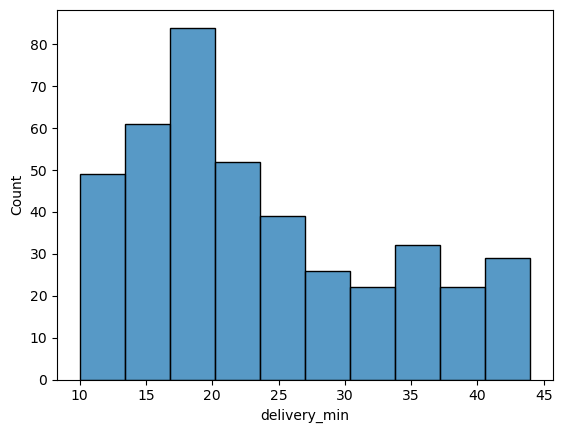

In [11]:
sb.histplot(x = "delivery_min", data = sunny_3_5)

##### Feature Variables and Target Variable Correlations

<Axes: >

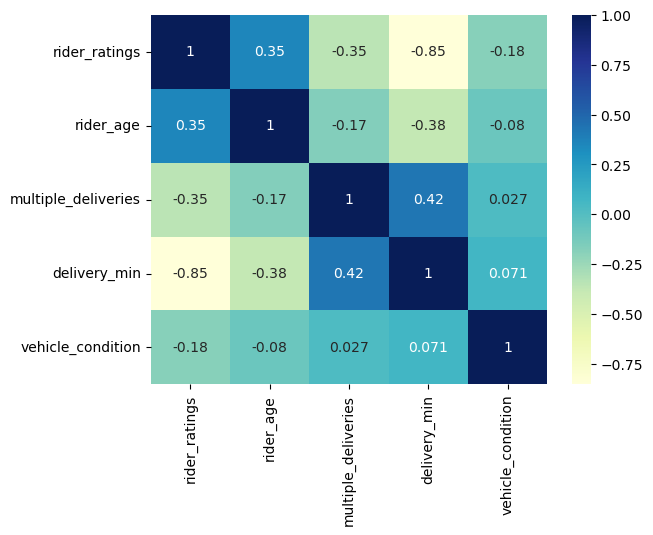

In [13]:
sunny_3_5[["rider_ratings","rider_age", "multiple_deliveries", "delivery_min","vehicle_condition"]].corr()
sb.heatmap(sunny_3_5[["rider_ratings","rider_age", "multiple_deliveries", "delivery_min","vehicle_condition"]].corr(), cmap = "YlGnBu",  annot = True)

##### The rider's ratings and delivery time have strongly negative linear relationship
##### The rirder's ratings and rider's age and number of multiple deliveries havs moderately 
##### postive and negative linear relationship, respectively.

<Axes: xlabel='rider_ratings', ylabel='Count'>

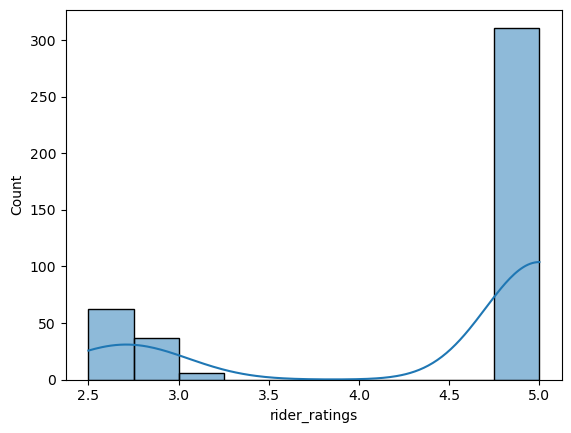

In [15]:
sb.histplot(x = "rider_ratings", data = sunny_3_5, kde = True)

In [16]:
sunny_3_5[sunny_3_5["rider_ratings"] == 5]["delivery_min"].mean()

18.977491961414792

In [17]:
# Dummy Varible "rating_5" for "ratings equal to 5": 1, if not 0
sunny_3_5["ratings_5"] = (sunny_3_5["rider_ratings"] == 5).astype(int)

In [18]:
sunny_3_5["ratings_5"]

0      0
1      0
2      0
3      0
4      0
      ..
411    1
412    1
413    1
414    1
415    1
Name: ratings_5, Length: 416, dtype: int32

In [19]:
# Dummy Variable "delivery_30" for "Delivery time greater less than 30": 1, if not 0.
sunny_3_5["delivery_30"] = (sunny_3_5["delivery_min"] < 30).astype(int)

In [38]:
# Dummy variable "multiple_flag" for if the riders have 1 or more deliveries, if not 0.
sunny_3_5["multiple_deliveries"].value_counts()
sunny_3_5["multiple_flag"] = (sunny_3_5["multiple_deliveries"] >= 1.0).astype(int)
sunny_3_5["multiple_flag"].value_counts()

multiple_flag
1    257
0    159
Name: count, dtype: int64

In [42]:
X = sunny_3_5[["delivery_30", "rider_age", "multiple_flag"]] # feature variables of interest
X = sm.add_constant(X) # 1로 이우러진 컬럼 추가 -> 절편항 추정
y = sunny_3_5["rider_ratings"]

model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          rider_ratings   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     7309.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:18:52   Log-Likelihood:                 241.66
No. Observations:                 416   AIC:                            -475.3
Df Residuals:                     412   BIC:                            -459.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.6867      0.036     74.053

##### The OLS result shows that on average, deliveries made under 30-minute period have 2.26 higher ratings than the deliveries made over 30-minute period keeping the rider's age and number of deliveries constant.

In [45]:
# Ordinal Logistic Regression is
# X = sunny_3_5[["delivery_min"]] - 30 # feature variables of interest
# X = sm.add_constant(X) # 1로 이우러진 컬럼 추가 -> 절편항 추정
# y = 

In [47]:
# Convert to a simpler ordinal scale, e.g., 0, 1, 2
y = sunny_3_5["rider_ratings"]
y = (y // 1.5).astype(int) 
y.value_counts()

rider_ratings
3    311
1     99
2      6
Name: count, dtype: int64

##### Predict rider's ratings using feature variables of interest 

##### Reparametrize Delivery time : (delivery - 30) for more intuitive interpretation of regression coefficients
- X = (delivery_min - 30)

In [51]:
# Reparametrize Delivery time :   (delivery - 30)
X1 = sunny_3_5[["delivery_min"]] - 30 
X = sunny_3_5[["rider_age","multiple_flag"]] # feature variables of interest
X_frames = [X1, X]
X= pd.concat(X_frames, axis = 1)
X

,delivery_min,rider_age,multiple_flag
0,12,24.0,1
1,4,23.0,1
2,11,29.0,1
3,13,20.0,1
4,13,23.0,1
...,...,...,...
411,-12,34.0,1
412,-10,23.0,1
413,-13,36.0,0
414,-5,33.0,1


                            OLS Regression Results                            
Dep. Variable:          rider_ratings   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     371.8
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          8.10e-117
Time:                        21:18:55   Log-Likelihood:                -316.35
No. Observations:                 416   AIC:                             640.7
Df Residuals:                     412   BIC:                             656.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.6297      0.139     26.068

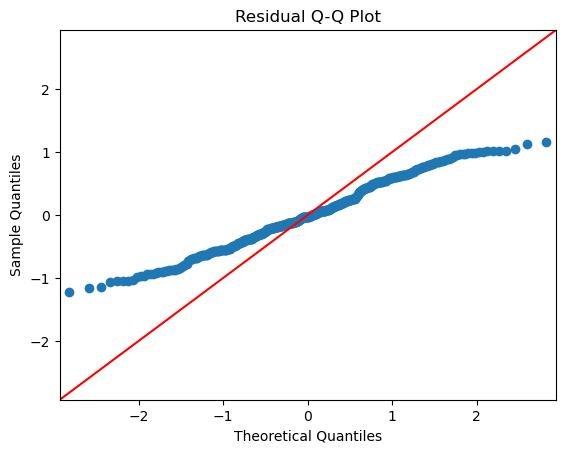

In [53]:
X = sm.add_constant(X) # 1로 이우러진 컬럼 추가 -> 절편항 추정
y = sunny_3_5["rider_ratings"]

model = sm.OLS(y,X).fit()
print(model.summary())
from statsmodels.graphics.gofplots import qqplot

fig = qqplot(model.resid, line='45')
plt.title("Residual Q-Q Plot")
plt.show()

##### The OLS result shows that on average, when delivery time is equal to 30 minutes, the riders' ratings is 3.6 while keeping the rider's age and number of multiple deliveries constant. 

##### On average, for every 1-minute increase in delivery time, the rider's ratings  decrease by 0.09  while keeping the rider's age and number of multiple deliveries constant.

##### This linear regression model has R^2 = 0.73, and rider's age and number of multiple deliveries are found to be statistically not  significant in this model.


In [56]:
#### Fit linear model with just reparametrized delivery time variable

                            OLS Regression Results                            
Dep. Variable:          rider_ratings   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     1110.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          3.07e-119
Time:                        21:26:55   Log-Likelihood:                -317.80
No. Observations:                 416   AIC:                             639.6
Df Residuals:                     414   BIC:                             647.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            3.8342      0.031    123.517   

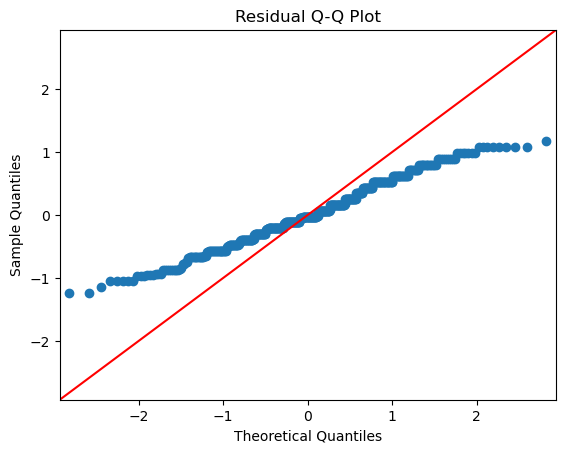

In [97]:
X1 = sunny_3_5[["delivery_min"]] - 30 
X = sm.add_constant(X1) # 1로 이우러진 컬럼 추가 -> 절편항 추정
y = sunny_3_5["rider_ratings"]

model = sm.OLS(y,X).fit()
print(model.summary())
#Predict the value: when delivery min is 40


from statsmodels.graphics.gofplots import qqplot

fig = qqplot(model.resid, line='45')
plt.title("Residual Q-Q Plot")
plt.show()

##### The OLS result shows that on average, when delivery time is equal to 30 minutes, the riders' ratings is 3.8.

##### On average, for every 1-minute increase in delivery time, the rider's ratings  decrease by 0.09.

##### This linear regression model has R^2 = 0.73

##### Final estimated linear regression model 
- Ratings = 3.8342 - 0.0917*(Delivery time - 30)

##### Using the final linear regression model 
- We can predict the ratings of different delivery time scenarios:
    - Scenario 1: Delivery time: 37 minutes (average delivery time or ratings <= 3)
        - Ratings = 3.8342 - 0.0917(37-30) = 3.19
    - Scenario 2: Delivery time: 30 minutes
        - Ratings = 3.8342 - 0.0917*(30 - 30) = 3.83 
    - Scenario 3: Delivery time: 20 minutes
        - Ratings = 3.842 - 0.0917*(20-30) = 4.75
- Scenario 4: If we have a specific target rating:
    - Ratings 4.5: 3.8342 - 0.0917(Delivery time - 30) => Delivery time = 22.74 

- Possible solution for better riders' performance, better ratings
  
    - Scenario 1 and 2:
        - If the delivery time of a rider can be improved from 37 minutes to 30 minutes, which is about 23% improvement, we can expect an improvement in riders' ratings from 3.19 to 3.8, which is about 16% improvement.
     
    - Scenario 4:
        - If a rider aims for 4.5 ratings, riders are expected to keep the delivery time of about 22 minutes on sunny and low traffic conditions. 




#### Conclusion: 

In [63]:
from sklearn.model_selection import train_test_split
X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 123)

In [64]:
##### Model Evaluation 
# 선형  회귀
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# 예측값 생성 - X_test_scaled /y_test

# Linear model
y_pred_lr = model_lr.predict(X_test)
# # SVM
# y_pred_svr= model_svr.predict(X_test_scaled)
# # Random forest
# y_pred_rfr = model_rfr.predict(X_test_scaled)

In [67]:
model_lr.coef_

array([ 0.        , -0.09279614])

In [69]:
y_pred_lr

array([5.504191  , 2.99869518, 5.31859871, 4.48343344, 4.94741415,
       4.66902572, 2.99869518, 5.59698714, 4.85461801, 2.62751062,
       4.94741415, 5.504191  , 3.74106431, 2.8131029 , 2.99869518,
       4.66902572, 5.22580257, 4.48343344, 3.9266566 , 3.46267589,
       5.22580257, 5.68978328, 4.11224888, 3.55547203, 5.04021029,
       5.13300643, 5.22580257, 2.90589904, 4.20504502, 5.31859871,
       4.85461801, 5.31859871, 2.62751062, 3.36987975, 3.46267589,
       4.85461801, 4.76182187, 2.90589904, 5.504191  , 4.01945274,
       4.85461801, 4.48343344, 5.504191  , 4.57622958, 5.41139485,
       4.29784116, 4.3906373 , 4.01945274, 4.29784116, 5.13300643,
       5.22580257, 2.8131029 , 5.68978328, 5.13300643, 5.41139485,
       4.01945274, 3.74106431, 4.85461801, 5.13300643, 4.76182187,
       3.18428747, 4.48343344, 5.41139485, 5.04021029, 3.46267589,
       4.76182187, 5.31859871, 3.36987975, 5.04021029, 4.20504502,
       5.22580257, 5.13300643, 4.57622958, 5.31859871, 4.94741

In [71]:
# 각 모형의 평가 지표 구하기

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# MAPE : Mean Absolute Percentage Error of Linear regressor
# using 답안지:  y_test, 모델  예측: y_pred_lr
mean_absolute_percentage_error(y_test, y_pred_lr)


print(mean_absolute_error(y_test, y_pred_lr))
print(mean_squared_error(y_test, y_pred_lr))
print(mean_absolute_percentage_error(y_test, y_pred_lr))

0.4442370935488584
0.2840142052154878
0.1095088217189931


In [73]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
model_rfr = RandomForestRegressor(random_state = 123)
model_rfr.fit(X_train, y_train)

RandomForestRegressor(random_state=123)

In [74]:
model_rfr.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 123,
 'verbose': 0,
 'warm_start': False}

In [77]:
# random forest 각 변수의 중요도 보기 ㅣ
model_rfr.feature_importances_

array([0., 1.])

In [79]:
#  예측값 생성
y_pred_rfr = model_rfr.predict(X_test)

In [81]:
y_pred_rfr

array([5.        , 2.73962607, 5.        , 5.        , 5.        ,
       5.        , 2.73962607, 5.        , 5.        , 2.69019441,
       5.        , 5.        , 2.71317226, 2.72824762, 2.73962607,
       5.        , 5.        , 5.        , 5.        , 2.7007776 ,
       5.        , 5.        , 5.        , 2.93545101, 5.        ,
       5.        , 5.        , 2.87955069, 5.        , 5.        ,
       5.        , 5.        , 2.69019441, 2.63110612, 2.7007776 ,
       5.        , 5.        , 2.87955069, 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.        ,
       5.        , 2.72824762, 5.        , 5.        , 5.        ,
       5.        , 2.71317226, 5.        , 5.        , 5.        ,
       2.7378381 , 5.        , 5.        , 5.        , 2.7007776 ,
       5.        , 5.        , 2.63110612, 5.        , 5.        ,
       5.        , 5.        , 5.        , 5.        , 5.     

In [83]:
# Random Forest 모델 평가지표
print(mean_absolute_error(y_test, y_pred_rfr))
print(mean_squared_error(y_test, y_pred_rfr))
print(mean_absolute_percentage_error(y_test, y_pred_rfr))

0.030282191279308864
0.005048915646186449
0.011205152768179667


In [85]:
##### 회귀분석 전 회귀분석 가정 체크하기 

<Axes: xlabel='rider_ratings', ylabel='delivery_min'>

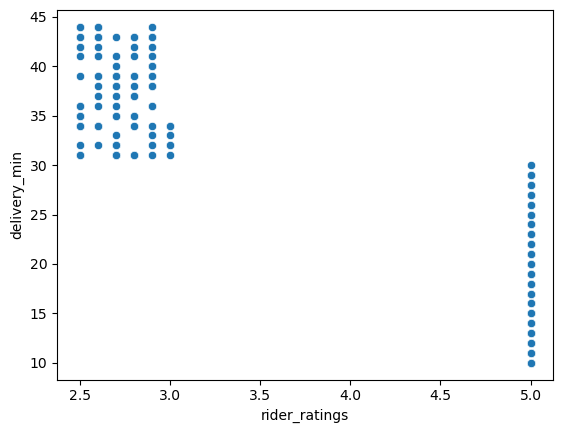

In [89]:
# 1. linearity 
sb.scatterplot(x = "rider_ratings", y= "delivery_min", data = sunny_3_5)

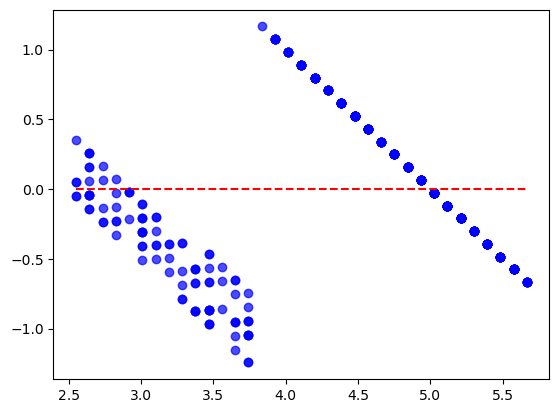

In [99]:
# 2. Homoscedasticity (Constant Variance of Errors)

# Residual Plot 

# Predict values and calculate residuals
y_pred = model.predict(X)
residuals = model.resid

# Create the residual plot
plt.scatter(y_pred, residuals, color='blue', alpha=0.7)
plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='red', linestyles='--') # Add a horizontal line at y=0

In [108]:
# 3. Independence of Residuals: Durbin Watson Test: A value close to 2 indicates no autocorrelation (errors are independent)
#statsmodels.graphics.tsa.plot_acf
dw_statistic = durbin_watson(residuals)
dw_statistic

1.535943677956888